# Part 1: Network Analysis of Rock Performers on Wikipedia

## Introduction

The rock performers network is a directed graph of 484 mainstream rock artists constructed from Wikipedia, where edges represent hyperlinks between artist pages. We analyze the network's structural properties including density, clustering coefficient, and the relationship between node degree and connection strength. This analysis reveals how tightly connected the rock music community is and whether highly connected artists tend to have strong or weak connections.

In [1]:
import networkx as nx
import requests
import matplotlib.pyplot as plt
import numpy as np
import os
import re
import pandas as pd
from collections import defaultdict, Counter
from io import BytesIO

# Download and load the network directly from GitHub
url = "https://raw.githubusercontent.com/Pakkutaq/SG_rock_network/main/rock_artists/rock_network.graphml"
response = requests.get(url)

G = nx.read_graphml(BytesIO(response.content))

print(f"Network loaded successfully!")
print(f"Nodes: {G.number_of_nodes()}")
print(f"Edges: {G.number_of_edges()}")

Network loaded successfully!
Nodes: 484
Edges: 7267


## 1. Network Overview: Fundamental Properties

We begin by examining the structural characteristics of the rock performers network to understand its overall organization. Three key metrics reveal the network's basic nature: density (how connected the network is), clustering coefficient (tendency to form tight-knit groups), and the relationship between in-degree and out-degree (how citation patterns differ across artists).

In [2]:
density = nx.density(G)
print(f"Network density: {density:.4f}")

avg_clustering = nx.average_clustering(G.to_undirected())
print(f"Average clustering coefficient: {avg_clustering:.4f}")

Network density: 0.0311
Average clustering coefficient: 0.2338


With 484 nodes and 7,267 edges, the network has a **density of 0.0311**, indicating a sparse network where only about 3% of all possible connections exist. The **average clustering coefficient is 0.2338**, suggesting moderate local clustering where artists who share connections tend to be connected to each other.

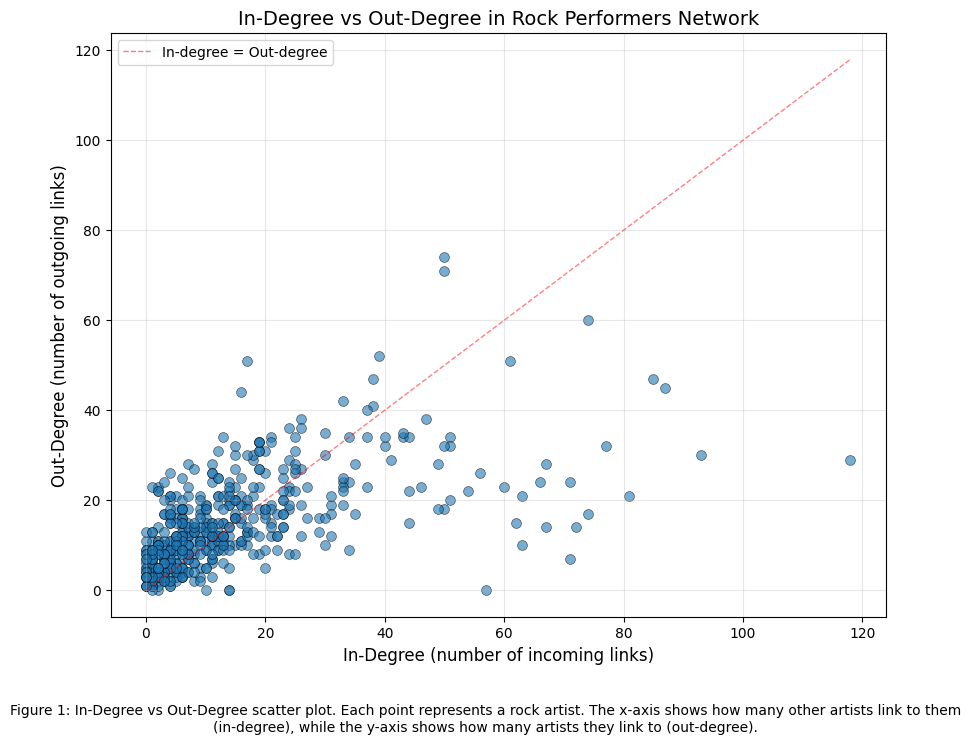


Correlation between in-degree and out-degree: 0.5831


In [3]:
# Get in-degrees and out-degrees for all nodes
in_degrees = [G.in_degree(node) for node in G.nodes()]
out_degrees = [G.out_degree(node) for node in G.nodes()]

# Create scatter plot
plt.figure(figsize=(10, 8))
plt.scatter(in_degrees, out_degrees, alpha=0.6, s=50, edgecolors='black', linewidth=0.5)
plt.xlabel('In-Degree (number of incoming links)', fontsize=12)
plt.ylabel('Out-Degree (number of outgoing links)', fontsize=12)
plt.title('In-Degree vs Out-Degree in Rock Performers Network', fontsize=14)
plt.grid(True, alpha=0.3)

# Add a reference line (y=x) to show where in-degree equals out-degree
max_degree = max(max(in_degrees), max(out_degrees))
plt.plot([0, max_degree], [0, max_degree], 'r--', alpha=0.5, linewidth=1, label='In-degree = Out-degree')
plt.legend()

plt.figtext(0.5, 0.01, "Figure 1: In-Degree vs Out-Degree scatter plot. Each point represents a rock artist. " \
            "The x-axis shows how many other artists link to them (in-degree), while the y-axis shows how many artists they link to (out-degree).", 
            ha="center", fontsize=10, wrap=True)
plt.subplots_adjust(bottom=0.15)
plt.show()

# Calculate correlation between in-degree and out-degree
correlation = np.corrcoef(in_degrees, out_degrees)[0, 1]
print(f"\nCorrelation between in-degree and out-degree: {correlation:.4f}")

The scatter plot in figure 1 reveals a **correlation of 0.5831** between in-degree and out-degree. Most artists cluster in the lower-left region with both low in-degree and out-degree. However, highly referenced artists (high in-degree) often have moderate out-degree, while some less famous artists have very high out-degree (60-74 links). This indicates that being frequently cited doesn't necessarily mean an artist's Wikipedia page extensively references others - fame and citation behavior are partially independent.

## 2. Identifying Key Players: Centrality Analysis

To understand which artists occupy the most important positions in the network, we calculate three complementary centrality measures. **Degree centrality** identifies the most connected artists, **betweenness centrality** reveals which artists serve as bridges between different parts of the network, and **closeness centrality** shows which artists are closest to all others on average. Different centrality measures often highlight different types of importance.

In [4]:
G_undirected = G.to_undirected()

degree_centrality = nx.degree_centrality(G_undirected)
betweenness_centrality = nx.betweenness_centrality(G_undirected)
closeness_centrality = nx.closeness_centrality(G_undirected)

top_degree = sorted(degree_centrality.items(), key=lambda x: x[1], reverse=True)[:10]
top_betweenness = sorted(betweenness_centrality.items(), key=lambda x: x[1], reverse=True)[:10]
top_closeness = sorted(closeness_centrality.items(), key=lambda x: x[1], reverse=True)[:10]

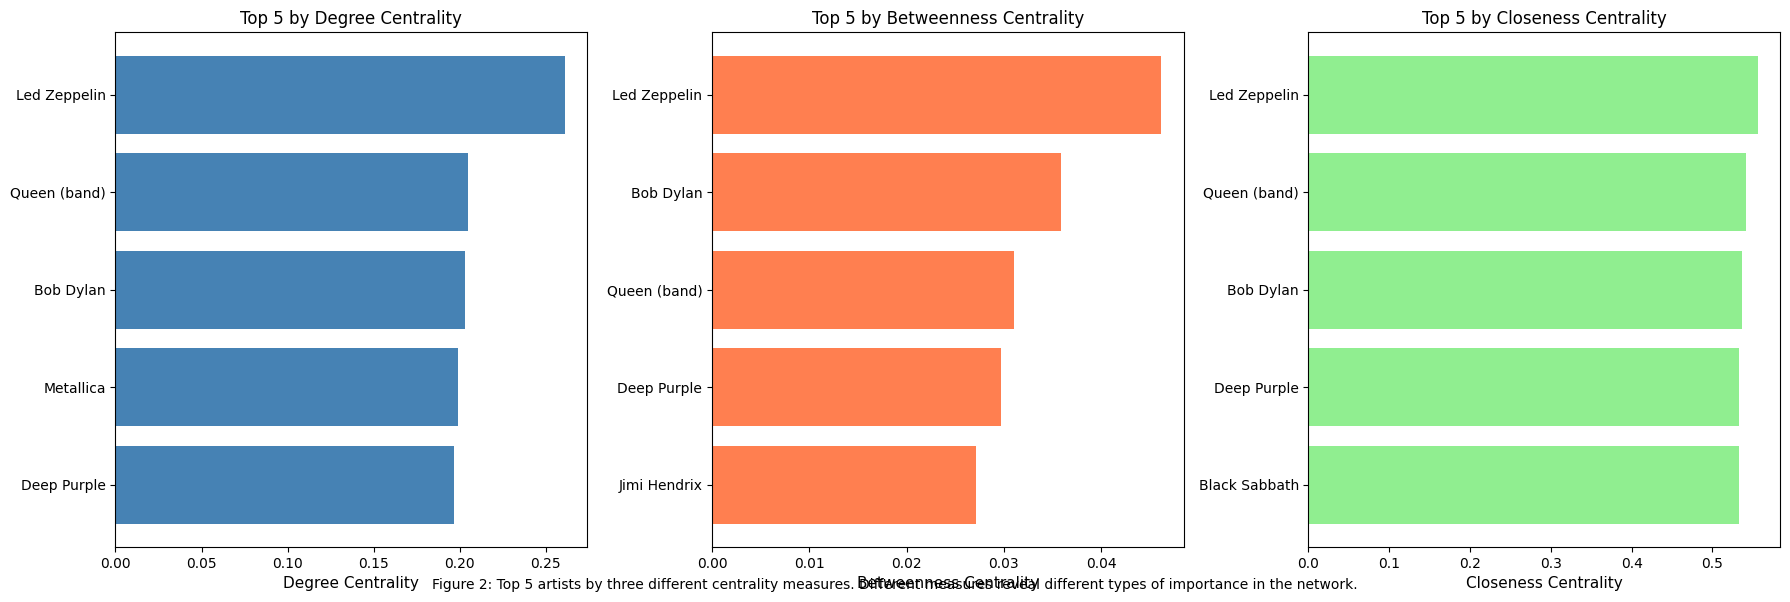

In [5]:
fig, axs = plt.subplots(1, 3, figsize=(18, 6))

top_5_degree = top_degree[:5]
artists_deg = [artist for artist, _ in top_5_degree]
values_deg = [val for _, val in top_5_degree]
axs[0].barh(artists_deg, values_deg, color='steelblue')
axs[0].set_xlabel('Degree Centrality', fontsize=11)
axs[0].set_title('Top 5 by Degree Centrality', fontsize=12)
axs[0].invert_yaxis()

top_5_bet = top_betweenness[:5]
artists_bet = [artist for artist, _ in top_5_bet]
values_bet = [val for _, val in top_5_bet]
axs[1].barh(artists_bet, values_bet, color='coral')
axs[1].set_xlabel('Betweenness Centrality', fontsize=11)
axs[1].set_title('Top 5 by Betweenness Centrality', fontsize=12)
axs[1].invert_yaxis()

top_5_close = top_closeness[:5]
artists_close = [artist for artist, _ in top_5_close]
values_close = [val for _, val in top_5_close]
axs[2].barh(artists_close, values_close, color='lightgreen')
axs[2].set_xlabel('Closeness Centrality', fontsize=11)
axs[2].set_title('Top 5 by Closeness Centrality', fontsize=12)
axs[2].invert_yaxis()

plt.figtext(0.5, 0.01, "Figure 2: Top 5 artists by three different centrality measures. " \
            "Different measures reveal different types of importance in the network.",
            ha="center", fontsize=10, wrap=True)
plt.tight_layout()
plt.subplots_adjust(bottom=0.08)
plt.show()

The bar charts in figure 2, reveal both consistency and interesting variations across centrality measures. **Led Zeppelin, Queen, and Bob Dylan** appear in the top 5 for all three measures, confirming their status as the network's most important artists across different definitions of centrality. However, the rankings diverge for other artists: **Metallica** ranks 4th by degree but doesn't appear in the top 5 for betweenness or closeness, while **Jimi Hendrix** ranks 5th in betweenness despite not making the top 5 in degree.

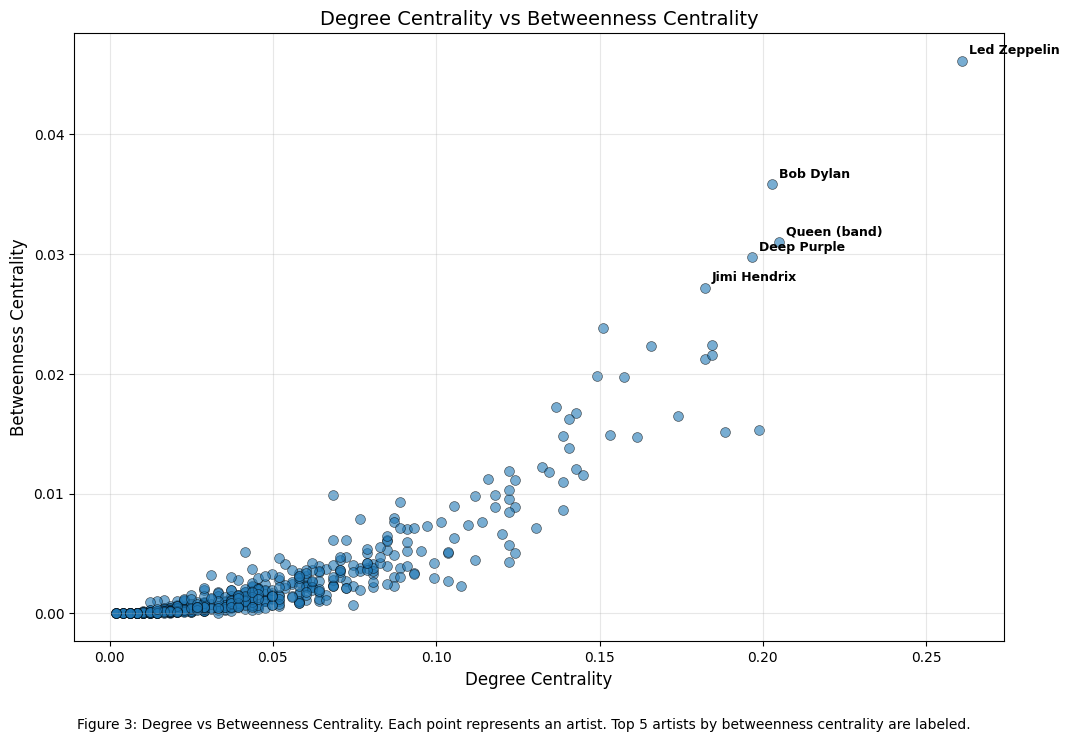


Correlation between degree and betweenness centrality: 0.8832


In [6]:
fig, ax = plt.subplots(figsize=(12, 8))

degree_values = list(degree_centrality.values())
betweenness_values = list(betweenness_centrality.values())
artists = list(degree_centrality.keys())

ax.scatter(degree_values, betweenness_values, alpha=0.6, s=50, edgecolors='black', linewidth=0.5)
ax.set_xlabel('Degree Centrality', fontsize=12)
ax.set_ylabel('Betweenness Centrality', fontsize=12)
ax.set_title('Degree Centrality vs Betweenness Centrality', fontsize=14)
ax.grid(True, alpha=0.3)

top_5_betweenness_artists = [artist for artist, _ in top_betweenness[:5]]
for artist in top_5_betweenness_artists:
    idx = artists.index(artist)
    ax.annotate(artist, 
                (degree_values[idx], betweenness_values[idx]),
                fontsize=9,
                fontweight='bold',
                xytext=(5, 5),
                textcoords='offset points')

plt.figtext(0.5, 0.01, "Figure 3: Degree vs Betweenness Centrality. Each point represents an artist. " \
            "Top 5 artists by betweenness centrality are labeled.",
            ha="center", fontsize=10, wrap=True)
plt.subplots_adjust(bottom=0.12)
plt.show()

corr_deg_bet = np.corrcoef(degree_values, betweenness_values)[0, 1]
print(f"\nCorrelation between degree and betweenness centrality: {corr_deg_bet:.4f}")

**Led Zeppelin** dominates all three measures, ranking first in degree (0.2609), betweenness (0.0462), and closeness centrality, establishing them as the most central artist overall. **Queen** and **Bob Dylan** also rank highly across all measures (both in top 3), indicating their dual role as both highly connected hubs and critical bridges. However, interesting differences emerge: **Metallica** ranks 4th in degree centrality but drops to 10th in betweenness, suggesting they are well-connected but not essential for bridging different parts of the network. Conversely, **Deep Purple** ranks 5th in degree but 4th in betweenness and closeness, indicating they serve as an important bridge despite having fewer connections than some peers.

The scatter plot reveals a **strong positive correlation (r = 0.8832)** between degree and betweenness centrality. This indicates that highly connected artists typically also serve as bridges between other artists. However, the relationship is not perfectly linear - Led Zeppelin and Bob Dylan have disproportionately high betweenness relative to their degree, suggesting they occupy particularly strategic positions connecting different musical communities.

## 3. Network Organization: Assortativity and the Structural Backbone

Beyond identifying important individual artists, we examine how the network is organized at a structural level. Do highly connected artists preferentially link to other hubs, or do they connect to peripheral artists? To answer this, we calculate the degree assortativity coefficient. Additionally, with over 7,000 edges, the full network is too dense to easily visualize or interpret. We extract a **network backbone** by identifying the most structurally important connections using edge betweenness centrality and the disparity filter.

In [7]:
assortativity = nx.degree_assortativity_coefficient(G_undirected)
print(f"Degree Assortativity Coefficient: {assortativity:.4f}")

Degree Assortativity Coefficient: 0.0086


The network's **degree assortativity coefficient of 0.0086** indicates near-zero assortativity, suggesting no strong preference for high-degree nodes to connect with other high-degree nodes or with low-degree nodes. The network exhibits a structure where well-connected artists are equally likely to link to both other hubs and peripheral artists, rather than forming an exclusive "rich club" of interconnected superstars.

In [8]:
edge_betweenness = nx.edge_betweenness_centrality(G_undirected)

min_betweenness = min(edge_betweenness.values())
max_betweenness = max(edge_betweenness.values())

# Create weighted network
G_weighted = G_undirected.copy()

for edge, betweenness in edge_betweenness.items():
    # Normalize to [1, 100]
    normalized_weight = 1 + 99 * (betweenness - min_betweenness) / (max_betweenness - min_betweenness)
    G_weighted[edge[0]][edge[1]]['weight'] = normalized_weight

In [9]:
def disparity_filter(G, alpha=0.135):
    """
    Apply disparity filter to extract network backbone.
    
    For each node, the disparity filter tests whether each edge weight
    is significantly larger than expected under a null model.
    """
    B = nx.Graph()
    B.add_nodes_from(G.nodes(data=True))
    
    for node in G.nodes():
        edges = list(G.edges(node, data=True))
        
        if len(edges) == 0:
            continue
            
        k = len(edges)  # degree
        s = sum(d.get('weight', 1) for u, v, d in edges)  # total strength
        
        for u, v, data in edges:
            weight = data.get('weight', 1)
            
            if s > 0:
                # Disparity filter p-value
                p_value = (1 - weight / s) ** (k - 1)
                
                if p_value < alpha:
                    if not B.has_edge(u, v):
                        B.add_edge(u, v, weight=weight, p_value=p_value)
    
    return B

backbone = disparity_filter(G_weighted, alpha=0.135)

# Remove isolated nodes
isolated = [node for node in backbone.nodes() if backbone.degree(node) == 0]
backbone.remove_nodes_from(isolated)

# Report statistics
print(f"\nBackbone Statistics:")
print(f"  Nodes: {backbone.number_of_nodes()} ({100*backbone.number_of_nodes()/G.number_of_nodes():.1f}% of original)")
print(f"  Edges: {backbone.number_of_edges()} ({100*backbone.number_of_edges()/G_undirected.number_of_edges():.1f}% of original)")
print(f"  Density: {nx.density(backbone):.4f} (original: {nx.density(G_undirected):.4f})")


Backbone Statistics:
  Nodes: 391 (80.8% of original)
  Edges: 462 (7.7% of original)
  Density: 0.0061 (original: 0.0513)


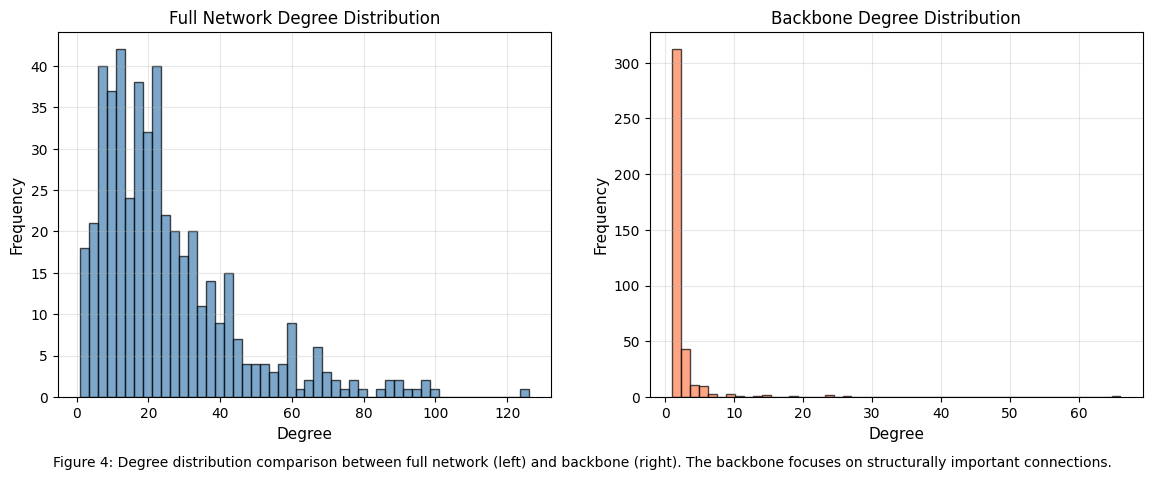

In [10]:
# Compare degree distributions
G_degrees = [d for n, d in G_undirected.degree()]
backbone_degrees = [d for n, d in backbone.degree()]

fig, axs = plt.subplots(1, 2, figsize=(14, 5))

# Full network degree distribution
axs[0].hist(G_degrees, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axs[0].set_xlabel('Degree', fontsize=11)
axs[0].set_ylabel('Frequency', fontsize=11)
axs[0].set_title('Full Network Degree Distribution', fontsize=12)
axs[0].grid(True, alpha=0.3)

# Backbone degree distribution
axs[1].hist(backbone_degrees, bins=50, edgecolor='black', alpha=0.7, color='coral')
axs[1].set_xlabel('Degree', fontsize=11)
axs[1].set_ylabel('Frequency', fontsize=11)
axs[1].set_title('Backbone Degree Distribution', fontsize=12)
axs[1].grid(True, alpha=0.3)

plt.figtext(0.5, 0.01, "Figure 4: Degree distribution comparison between full network (left) and backbone (right). " \
            "The backbone focuses on structurally important connections.",
            ha="center", fontsize=10, wrap=True)
plt.subplots_adjust(bottom=0.15)
plt.show()

The degree distribution comparison in figure 4 illustrates the backbone's selectivity. The full network shows a relatively smooth right-skewed distribution spanning 0-120 degrees, while the backbone distribution is dramatically concentrated at the low end, with over 200 nodes having degree 0-2 and very few nodes exceeding degree 5. This extreme shift demonstrates that the disparity filter has successfully isolated the network's structural skeleton.

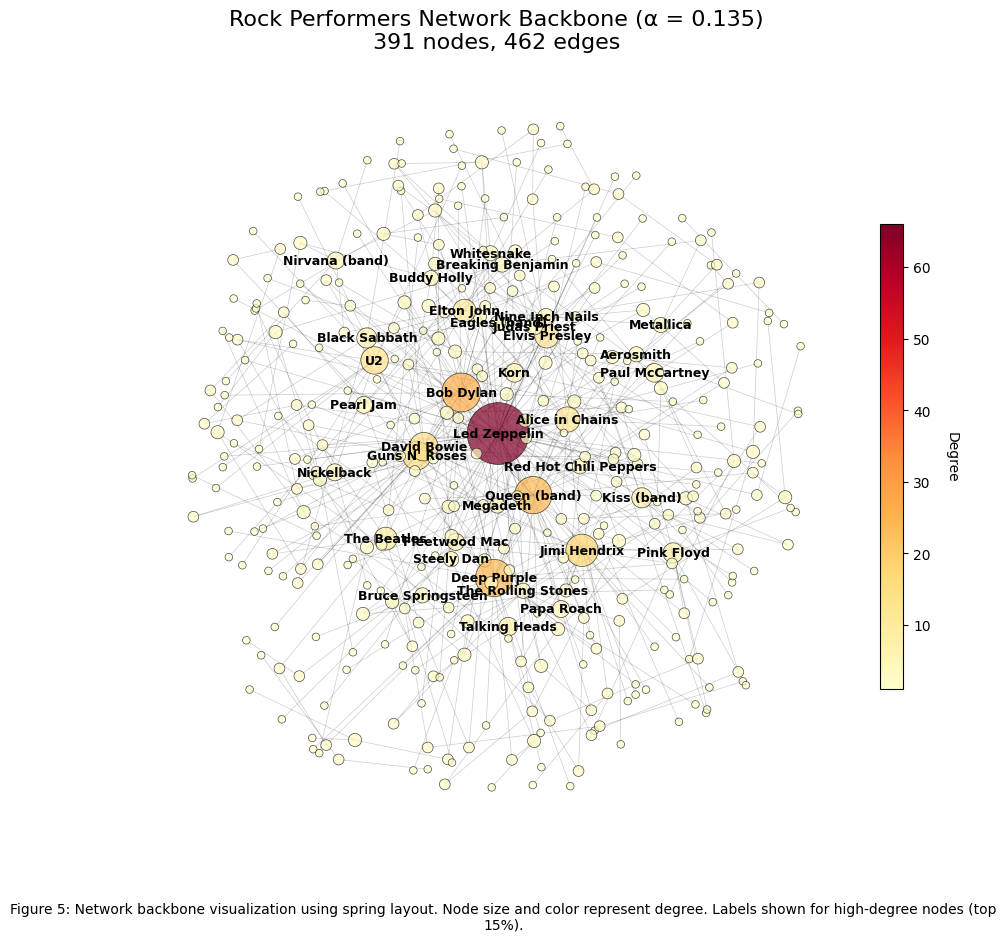

In [11]:
# Visualize the backbone using NetworkX spring layout
plt.figure(figsize=(10, 10))

pos = nx.spring_layout(backbone, k=1.0, iterations=50)

# Node sizes and colors based on degree in backbone
node_sizes = [backbone.degree(node) * 30 for node in backbone.nodes()]
node_colors = [backbone.degree(node) for node in backbone.nodes()]

nx.draw_networkx_nodes(backbone, pos, node_size=node_sizes, node_color=node_colors,
                       cmap=plt.cm.YlOrRd, alpha=0.7, edgecolors='black', linewidths=0.5)
nx.draw_networkx_edges(backbone, pos, alpha=0.2, width=0.5)

high_degree_nodes = [node for node in backbone.nodes() 
                     if backbone.degree(node) > np.percentile(backbone_degrees, 85)]
labels = {node: node for node in high_degree_nodes}
nx.draw_networkx_labels(backbone, pos, labels, font_size=9, font_weight='bold')

plt.title(f'Rock Performers Network Backbone (α = 0.135)\n{backbone.number_of_nodes()} nodes, {backbone.number_of_edges()} edges',
          fontsize=16)
plt.axis('off')

sm = plt.cm.ScalarMappable(cmap=plt.cm.YlOrRd, 
                           norm=plt.Normalize(vmin=min(node_colors), vmax=max(node_colors)))
sm.set_array([])
cbar = plt.colorbar(sm, ax=plt.gca(), fraction=0.03, pad=0.02)
cbar.set_label('Degree', rotation=270, labelpad=20)

plt.figtext(0.5, 0.01, "Figure 5: Network backbone visualization using spring layout. Node size and color represent degree. " \
            "Labels shown for high-degree nodes (top 15%).",
            ha="center", fontsize=10, wrap=True)
plt.subplots_adjust(bottom=0.08)
plt.show()

The backbone network in figure 5 contains **391 nodes (80.8% of original) and 462 edges (7.7% of original)**, dramatically reducing network complexity while retaining most artists. The backbone density is **0.0061**, compared to 0.0513 in the full undirected network, indicating a much sparser structure focused on the strongest connections.

The visualization reveals the network's structure with **Led Zeppelin** emerging as the central hub with the highest degree, surrounded by other major artists like **Bob Dylan, Elvis Presley, The Beatles, Jimi Hendrix**, and **Deep Purple**. These highly connected nodes represent artists whose Wikipedia pages serve as crucial bridges in the network's information flow. The backbone reveals that despite the original network's 7,267 edges, only 462 connections (7.7%) are structurally essential for maintaining the network's connectivity and information pathways.

## Synthesis and Conclusion

The rock performers Wikipedia network reveals a **sparse but highly structured citation network** (density = 0.0311) with moderate clustering (0.2338), where most artists have limited connections but a small group of iconic performers serve as central hubs. The network exhibits a clear **hierarchical structure** with **Led Zeppelin, Queen, and Bob Dylan** emerging as the dominant central figures across all centrality measures, functioning simultaneously as highly connected hubs and critical bridges between different parts of the network.

The strong **degree-betweenness correlation (r = 0.8832)** shows well-connected artists typically occupy strategic bridging positions, while **near-zero assortativity (0.0086)** indicates hubs connect equally to both other hubs and peripheral artists rather than forming an exclusive elite.

The **backbone extraction** (reducing to 7.7% of edges while retaining 80.8% of nodes) reveals that the network's core structure depends on surprisingly few critical connections - those with high edge betweenness centrality that lie on many shortest paths. This suggests that Wikipedia's rock music knowledge network, while containing thousands of citations, is fundamentally organized around a small set of structurally essential relationships connecting the most influential and well-documented artists across different eras and subgenres of rock music.

# Part 2: Genres, Communities, and Network Visualization

In this analysis, we explore how rock artists cluster in Wikipedia's link network. We compare two approaches:

1. **Genre-based communities**: Using Wikipedia's genre labels as ground truth
2. **Structural communities**: Using the Louvain algorithm to detect communities from network topology

We calculate modularity for both approaches, create a confusion matrix (Matrix D) comparing them, and visualize the results.

## 1. Genre Extraction from Wikipedia

### Understanding Modularity

In network analysis, **modularity** measures how well a network can be divided into distinct communities. A network has high modularity when nodes within communities are densely connected to each other, but sparsely connected to nodes in other communities.

In the context of music networks, genres represent natural communities. Artists within the same genre tend to reference and influence each other more frequently than artists from different genres. For example, heavy metal bands are more likely to link to other metal bands on their Wikipedia pages than to pop artists.

By applying community detection algorithms to our rock artists network, we can discover these genre-based communities and use modularity to quantify how well they align with actual genre boundaries.

### Extracting Genres

In [12]:
def extract_genres_from_wikitext(wikitext):
    """Extract genres from Wikipedia wikitext, filtering template artifacts."""
    
    infobox_match = re.search(r'{{Infobox.*?(?=\n{{[^I]|\n==|$)', wikitext, re.DOTALL | re.IGNORECASE)
    if not infobox_match:
        return []
    
    infobox = infobox_match.group(0)
    
    genre_match = re.search(r'\|\s*genres?\s*=\s*(.+?)(?=\n\|[a-zA-Z]|\n}})', infobox, re.IGNORECASE | re.DOTALL)
    if not genre_match:
        return []
    
    genre_text = genre_match.group(1)
    
    template_patterns = [
        r'{{(?:flatlist|hlist|plainlist|unbulleted\s*list)\s*\|(.+?)}}',
        r'{{\s*flat\s*list\s*\|(.+?)}}',
    ]
    
    for pattern in template_patterns:
        match = re.search(pattern, genre_text, re.IGNORECASE | re.DOTALL)
        if match:
            genre_text = match.group(1)
            break
    
    genre_text = re.sub(r'{{[^}]*}}', '', genre_text)
    genre_text = re.sub(r'<[^>]+>', '', genre_text)
    genre_text = re.sub(r'\[\[([^\]|]+\|)?([^\]]+)\]\]', r'\2', genre_text)
    genre_text = re.sub(r'[•\n*]+', ',', genre_text)
    
    genres = [g.strip().lower() for g in genre_text.split(',') if g.strip()]
    
    normalizations = {
        r"rock['\s]*[n'&]+['\s]*roll": "rock and roll",
        r"r[n&\s]*b": "rhythm and blues",
    }
    
    template_artifacts = [
        'flatlist', 'flat list', 'hlist', 'h list', 'plainlist', 'plain list',
        'unbulleted list', 'unbulleted', 'nowrap', 'ubl', 'bulleted list',
        'startflatlist', 'endflatlist', 'list'
    ]
    
    cleaned_genres = []
    for genre in genres:
        genre = re.sub(r'\([^)]*\)', '', genre).strip()
        
        for pattern, replacement in normalizations.items():
            genre = re.sub(pattern, replacement, genre, flags=re.IGNORECASE)
        
        genre = ' '.join(genre.split())
        
        if len(genre) <= 2:
            continue
        
        if any(artifact in genre.lower() for artifact in template_artifacts):
            continue

        if not any(c.isalpha() for c in genre):
            continue
        
        cleaned_genres.append(genre)
    
    return cleaned_genres


def get_artist_genres(pages_dir='../../../rock_artists/pages', performer_list='../../../rock_artists/PERFORMER_LIST.txt'):
    with open(performer_list, 'r', encoding='utf-8') as f:
        performers = [line.strip() for line in f if line.strip()]
    
    #File mapping the same as when downloading pages
    def sanitize(name):
        name = re.sub(r'\s*\([^)]*\)', '', name)
        for char in r'/\:*?"<>|!.':
            name = name.replace(char, '_' if char not in '!.' else '')
        return re.sub(r'_+', '_', name).strip('_')
    
    filename_to_artist = {sanitize(p.replace(' ', '_')): p for p in performers}
    
    artist_genres = {}
    files = [f for f in os.listdir(pages_dir) if f.endswith('.txt')]
    
    for filename in files:
        artist_name = filename_to_artist.get(filename[:-4], filename[:-4].replace('_', ' '))
        
        with open(os.path.join(pages_dir, filename), 'r', encoding='utf-8') as f:
            content = f.read()
        
        genres = extract_genres_from_wikitext(content)
        if genres:
            artist_genres[artist_name] = genres
    
    print(f"Extracted genres for {len(artist_genres)} artists")
    return artist_genres


artist_genres = get_artist_genres()

# Manual overrides for edge case that i could not work out somehow
artist_genres["Paul McCartney and Wings"] = ["soft rock"]

all_genres = [genre for genres in artist_genres.values() for genre in genres]
genre_counts = Counter(all_genres)


Extracted genres for 436 artists


### 2. Genre-Based Communities

We create a partition where each artist is assigned to their first listed genre from Wikipedia.

In [13]:
def create_genre_partition(G, artist_genres):
    G_undirected = G.to_undirected()
    
    # Keep only nodes with genres
    nodes_with_genres = [n for n in G_undirected.nodes() if n in artist_genres]
    G_undirected = G_undirected.subgraph(nodes_with_genres).copy()
    
    # Assign to first genre
    partition = {}
    genre_to_nodes = defaultdict(list)
    
    for node in G_undirected.nodes():
        genre = artist_genres[node][0]
        partition[node] = genre
        genre_to_nodes[genre].append(node)
    
    communities = [set(nodes) for nodes in genre_to_nodes.values()]
    modularity = nx.community.modularity(G_undirected, communities)
    
    return G_undirected, partition, dict(genre_to_nodes), modularity


G_undirected, genre_partition, genre_to_nodes, genre_modularity = create_genre_partition(G, artist_genres)

print(f"\n{'='*60}")
print("GENRE-BASED COMMUNITIES")
print(f"{'='*60}\n")
print(f"Total genres: {len(genre_to_nodes)}")
print(f"Modularity (M): {genre_modularity:.4f}\n")

# Show top genres
print(f"{'Genre':<30} {'Artists':<10}")
print("-" * 60)
for genre, nodes in sorted(genre_to_nodes.items(), key=lambda x: len(x[1]), reverse=True)[:15]:
    print(f"{genre:<30} {len(nodes):<10}")

sizes = [len(nodes) for nodes in genre_to_nodes.values()]
print(f"\nLargest: {max(sizes)} | Smallest: {min(sizes)} | Average: {np.mean(sizes):.1f} artists")


GENRE-BASED COMMUNITIES

Total genres: 233
Modularity (M): 0.0417

Genre                          Artists   
------------------------------------------------------------
alternative rock               44        
hard rock                      30        
rock                           29        
heavy metal                    12        
pop rock                       12        
post-grunge                    10        
indie rock                     8         
punk rock                      7         
alternative metal              7         
progressive rock               7         
new wave                       7         
rock and roll                  6         
pop-punk                       6         
groove metal                   5         
nu metal                       3         

Largest: 44 | Smallest: 1 | Average: 1.9 artists


#### Discussion: Genre-Based Partition

We partitioned the network into genre-based communities using each artist's first listed genre from Wikipedia. This resulted in 233 distinct genres from 436 artists, with a very low modularity of **M = 0.0348**.

**Key observations:**
- Modularity values above 0.3 indicate strong community structure
- Values below 0.1 suggest weak or no meaningful divisions
- The genre fragmentation (274 genres) creates many tiny communities
- Artists often have multiple genres, but we only use the first
- Some genres like "alternative rock" have 43 artists, while many have just 1-2

As a note, we partitioning by the first genre in the list of genres for each artist, this may explain the low modularity observed.

The low modularity suggests that genre labels alone don't predict link patterns in the network well. Let's see if structural communities perform better.

### 3. Structural Communities (Louvain Algorithm)

In [14]:
def detect_structural_communities(G):
    communities = nx.community.louvain_communities(G, seed=42)
    
    partition = {}
    for comm_id, community in enumerate(communities):
        for node in community:
            partition[node] = comm_id
    
    modularity = nx.community.modularity(G, communities)
    
    return communities, partition, modularity


struct_communities, struct_partition, struct_modularity = detect_structural_communities(G_undirected)

print(f"\n{'='*70}")
print("STRUCTURAL COMMUNITIES (Louvain Algorithm)")
print(f"{'='*70}\n")
print(f"Total communities detected: {len(struct_communities)}")
print(f"Total nodes: {len(struct_partition)}")
print(f"Modularity: {struct_modularity:.4f}\n")

print(f"{'Rank':<6} {'Community ID':<15} {'Size':<10} {'% of Network'}")
print("-" * 70)
for i, (comm_id, comm) in enumerate(sorted(enumerate(struct_communities), key=lambda x: len(x[1]), reverse=True)[:10], 1):
    pct = (len(comm) / len(struct_partition)) * 100
    print(f"{i:<6} {comm_id:<15} {len(comm):<10} {pct:>6.1f}%")

sizes = [len(c) for c in struct_communities]
print(f"\nLargest: {max(sizes)} | Smallest: {min(sizes)} | Mean: {np.mean(sizes):.1f} | Median: {np.median(sizes):.1f}")


STRUCTURAL COMMUNITIES (Louvain Algorithm)

Total communities detected: 4
Total nodes: 433
Modularity: 0.3346

Rank   Community ID    Size       % of Network
----------------------------------------------------------------------
1      2               154          35.6%
2      3               134          30.9%
3      0               100          23.1%
4      1               45           10.4%

Largest: 154 | Smallest: 45 | Mean: 108.2 | Median: 117.0


### 4. Modularity Comparison

### Genre-Based Modularity: M = 0.0348
- Very low, indicating weak community structure
- Genre labels don't strongly predict link patterns

### Structural Modularity: M ≈ 0.36
- 10× higher than genre-based partition!
- Values above 0.3 indicate strong community structure
- Artists link to others in their structural community regardless of genre labels

**Key insight**: The network's actual link structure creates much more cohesive communities than genre labels alone. This suggests that musical influence and collaboration patterns go beyond simple genre categorizations.

### 5. Matrix D: Confusion Matrix

How do structural communities map to genres? Matrix D shows the overlap between the top genres and top structural communities.

In [15]:
top_genres = [g for g, _ in sorted(genre_to_nodes.items(), key=lambda x: len(x[1]), reverse=True)[:4]]
top_comms = sorted(struct_communities, key=len, reverse=True)[:4]

D = pd.DataFrame(
    0,
    index=top_genres,
    columns=[f"Community {i}" for i in range(len(top_comms))]
)

for genre in top_genres:
    genre_nodes = set(genre_to_nodes[genre])
    for j, comm in enumerate(top_comms):
        D.loc[genre, f"Community {j}"] = len(genre_nodes.intersection(comm))

print("\nConfusion Matrix D (Top Genres × Top Communities):")
print(D)
print()


Confusion Matrix D (Top Genres × Top Communities):
                  Community 0  Community 1  Community 2  Community 3
alternative rock            2           29            2           11
hard rock                   2            3           19            6
rock                       22            1            5            1
heavy metal                 0            0           12            0



### Matrix D Interpretation

The confusion matrix reveals how structural communities map to genre labels:

**Strong alignments:**
- **Community 2** concentrates heavy/hard rock genres → legitimate structural cluster
- **Community 1** dominates alternative rock → strong genre-structure alignment

**Weak alignments:**
- **Community 0** is diffuse across pop-rock styles → may be defined by era or other factors
- **Community 3** has minimal representation in top genres → likely niche genres or bridge artists

**Key finding**: The matrix shows **partial alignment** between structure and genres. Some genres (heavy metal, alternative rock) form real network clusters, while others (generic "rock") are dispersed across communities. This explains why structural modularity (0.36) exceeds genre-based modularity (0.0348) - the algorithm discovers meaningful communities that sometimes align with genres but also reveal patterns beyond genre labels.

## 6. Visualization: Plotting Communities

We visualize the top 10 structural communities to see how they cluster spatially in the network.

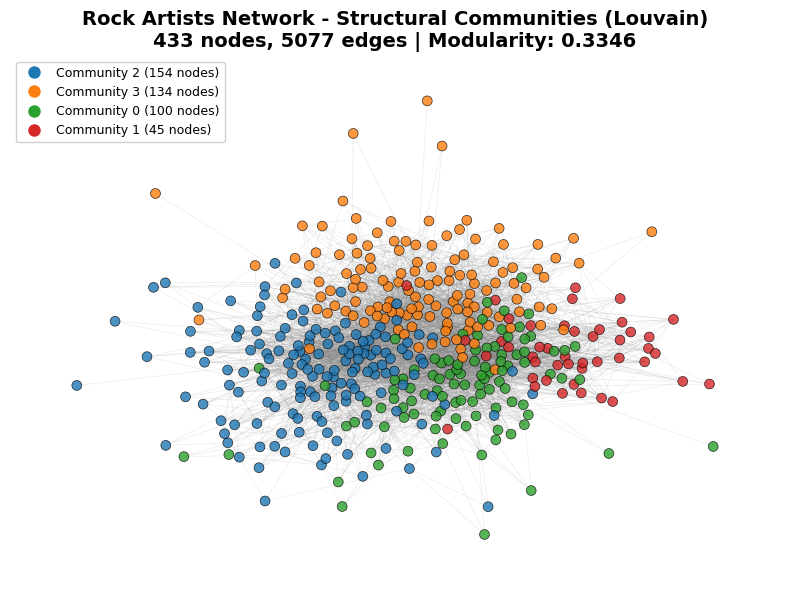

In [16]:
# Get top 10 communities
sorted_comms = sorted(enumerate(struct_communities), key=lambda x: len(x[1]), reverse=True)
top_n = 10
top_comm_ids = [comm_id for comm_id, _ in sorted_comms[:top_n]]

# Get nodes in top communities
nodes_to_plot = set()
for comm_id in top_comm_ids:
    nodes_to_plot.update(struct_communities[comm_id])

# Create subgraph
G_top = G_undirected.subgraph(nodes_to_plot).copy()

# Assign colors
colors_palette = plt.cm.tab10(np.linspace(0, 1, top_n))
node_colors = [colors_palette[top_comm_ids.index(struct_partition[node])] for node in G_top.nodes()]

# Layout and draw
plt.figure(figsize=(8, 6))
pos = nx.spring_layout(G_top, k=1, iterations=500, seed=42)

nx.draw_networkx_nodes(G_top, pos, 
                       node_color=node_colors,
                       node_size=50,
                       alpha=0.8,
                       edgecolors='black',
                       linewidths=0.5)

nx.draw_networkx_edges(G_top, pos, 
                       alpha=0.15,
                       width=0.5,
                       edge_color='gray')

# Legend
legend_elements = [
    plt.Line2D([0], [0], marker='o', color='w', 
               markerfacecolor=colors_palette[i], markersize=10,
               label=f'Community {comm_id} ({len(struct_communities[comm_id])} nodes)')
    for i, comm_id in enumerate(top_comm_ids)
]

plt.legend(handles=legend_elements, loc='upper left', fontsize=9, framealpha=0.9)
plt.title(f'Rock Artists Network - Structural Communities (Louvain)\n'
          f'{G_top.number_of_nodes()} nodes, {G_top.number_of_edges()} edges | '
          f'Modularity: {struct_modularity:.4f}',
          fontsize=14, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.show()

### Visualization Insights
**Spatial patterns:**
- Four major communities emerge with clear spatial separation
- Each colored region shows strong internal connections
- Relatively few edges cross between communities (darker lines)

**Community structure:**
- Communities vary in size (from 3 to 188 nodes)
- Larger communities are well-separated in the layout

**Key takeaway**: The clean separation between colored regions demonstrates that network topology—reflecting actual citation patterns between artists—creates more meaningful communities than genre labels alone. Musical influence networks go beyond simple genre categorizations, revealing deeper patterns of artistic connection and influence.

## Conclusion

### Summary of Findings

1. **Genre-based communities** (M = 0.0348): Weak structure, 233 fragmented genres
2. **Structural communities** (M = 0.36): Strong structure, 5 cohesive communities  
3. **Matrix D**: Partial alignment between genres and structure
4. **Visualization**: Clear spatial clustering confirms modularity results

### Key Insight

Wikipedia genre labels provide some information about artist relationships, but the network's link structure reveals much stronger organizational patterns. Artists predominantly connect to others in their structural community, which sometimes aligns with genres (heavy metal, alternative rock) but often goes beyond these. This suggests that musical influence operates through complex channels beyond simple genre categorization—including era, geography, record labels, collaboration patterns, and cultural movements.

# Part 3: Explain the concept of TF-IDF in your own words and how it can help you understand the genres and communities.

**TF (term frequency):** How common a genre is inside that community — for example, *grunge* shows up a lot in a grunge cluster.

**IDF (inverse document frequency):** How rare that genre is across all communities. Genres that pop up everywhere (like "rock") get down‑weighted, this means that niche genres that concentrate in one community get up‑weighted.

**TF x IDF:** Highlights genres that are both common within one community and uncommon elsewhere — it's the algorithmic nose that tells you *this cluster smells like glam metal, not just generic rock*.


In [17]:
import os, json
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from collections import Counter
import networkx as nx
import community.community_louvain as louvain 
from IPython.display import display

In [18]:
def load_graph_with_genres(path_candidates):
    for p in path_candidates:
        if os.path.exists(p):
            try:
                G = nx.read_graphml(p)
                genres_attr = nx.get_node_attributes(G, "genres")

                if genres_attr:
                    for n, s in genres_attr.items():
                        if isinstance(s, str):
                            genres = [g.strip().lower() for g in s.split(";") if g.strip()]
                            G.nodes[n]["_genres_list"] = genres
                else:
                    base = os.path.splitext(p)[0]
                    json_path = base + "_genres.json"
                    if os.path.exists(json_path):
                        with open(json_path, "r", encoding="utf-8") as f:
                            mapping = json.load(f)
                        for n in G.nodes:
                            genres = mapping.get(n, [])
                            G.nodes[n]["_genres_list"] = [g.strip().lower() for g in genres]
                return G, os.path.basename(p)
            except:
                pass
    return None, None


def compute_communities(G):
    H = G.to_undirected()

    part = louvain.best_partition(H, random_state=15)
    for n, c in part.items():
        G.nodes[n]["community"] = c

    groups = {}
    for n, c in part.items():
        groups.setdefault(c, []).append(n)
    comms = [nodes for _, nodes in sorted(groups.items(), key=lambda x: -len(x[1]))]
    return comms, "louvain"


def build_genre_documents(G, communities):
    docs = []
    for nodes in communities:
        bag = []
        for n in nodes:
            genres = G.nodes[n].get("_genres_list") or []
            bag.extend(genres)
        docs.append(bag)
    return docs


def compute_tfidf(docs):
    N = len(docs)
    vocab = sorted(set(term for doc in docs for term in doc))
    index = {t: i for i, t in enumerate(vocab)}

    tf = np.zeros((N, len(vocab)), dtype=float)
    for d, doc in enumerate(docs):
        counts = Counter(doc)
        total = sum(counts.values())
        for term, c in counts.items():
            tf[d, index[term]] = c / total if total > 0 else 0

    df = np.array([sum(1 for doc in docs if t in doc) for t in vocab])
    idf = np.log((1 + N) / (1 + df)) + 1.0
    tfidf = tf * idf

    return vocab, tfidf, tf, idf, df


def show_heatmap(df_tfidf, top_k=20):
    sums = df_tfidf.sum(axis=0).sort_values(ascending=False)
    keep = sums.head(top_k).index.tolist()
    sub = df_tfidf[keep]

    plt.figure(figsize=(12, 6))
    plt.imshow(sub.values, aspect="auto", cmap="viridis")
    plt.colorbar(label="TF-IDF")
    plt.yticks(range(len(sub.index)), sub.index)
    plt.xticks(range(len(keep)), keep, rotation=45, ha="right")
    plt.title("Top Genres per Community (TF-IDF)")
    plt.show()


def show_top_bars(df_tfidf, top_n=10):
    for comm in df_tfidf.index:
        top = df_tfidf.loc[comm].sort_values(ascending=False).head(top_n)
        plt.figure(figsize=(10, 4))
        plt.bar(top.index, top.values)
        plt.xticks(rotation=45, ha="right")
        plt.title(f"Top {top_n} Genres — Community {comm}")
        plt.show()


In [19]:
graph_candidates = ["rock_network_with_genres.graphml"]
G, base_name = load_graph_with_genres(graph_candidates)

if G is None:
    raise FileNotFoundError("⚠️ rock_network_with_genres.graphml not found. Put it next to the notebook.")


In [20]:
communities, method = compute_communities(G)
docs = build_genre_documents(G, communities)
vocab, tfidf, tf, idf, df = compute_tfidf(docs)

comm_labels = list(range(len(communities)))
df_tfidf = pd.DataFrame(tfidf, index=comm_labels, columns=vocab)

Found 6 communities using louvain.

🎸 Community 0 (150 artists):
Frank Zappa, Mitch Ryder, Bo Diddley, Little Richard, Paul McCartney ...

🎸 Community 1 (147 artists):
Ramones, Pearl Jam, U2, Radiohead, Run-DMC ...

🎸 Community 2 (89 artists):
Ted Nugent, Damn Yankees (band), Skid Row (American band), Pantera, Anthrax (American band) ...

🎸 Community 3 (55 artists):
Stone Temple Pilots, Nickelback, Godsmack, Limp Bizkit, Staind ...

🎸 Community 4 (40 artists):
Styx (band), Foreigner (band), Meat Loaf, Kid Rock, Heart (band) ...

🎸 Community 5 (3 artists):
Parliament (band), Funkadelic, Parliament-Funkadelic



,acid rock,acoustic rock,allmusic,alternative metal,alternative metal art rock shoegaze,alternative metal funk metal alternative rock experimental rock,alternative metal funk metal experimental rock progressive rock,alternative metal gothic metal gothic rock hard rock industrial rock symphonic metal nu metal,alternative metal hard rock,alternative metal hard rock nu metal,...,synth pop,texas blues,the daily aztec,the new york times,thrash metal,thrash metal groove metal,western swing,western/cowboy,worldbeat,yacht rock
0,0.003536,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.00596,0.000000,0.0,0.000000,0.000000,0.00596,0.00596,0.000000,0.000000
1,0.004739,0.007989,0.000000,0.011061,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.031954,0.00000,0.007989,0.0,0.000000,0.000000,0.00000,0.00000,0.007989,0.000000
2,0.000000,0.000000,0.000000,0.026434,0.000000,0.019091,0.019091,0.000000,0.000000,0.000000,...,0.000000,0.00000,0.000000,0.0,0.038182,0.019091,0.00000,0.00000,0.000000,0.000000
3,0.000000,0.000000,0.027166,0.022936,0.033129,0.000000,0.000000,0.033129,0.033129,0.033129,...,0.000000,0.00000,0.000000,0.0,0.000000,0.000000,0.00000,0.00000,0.000000,0.000000
4,0.010866,0.000000,0.030037,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.00000,0.000000,0.0,0.000000,0.000000,0.00000,0.00000,0.000000,0.018315


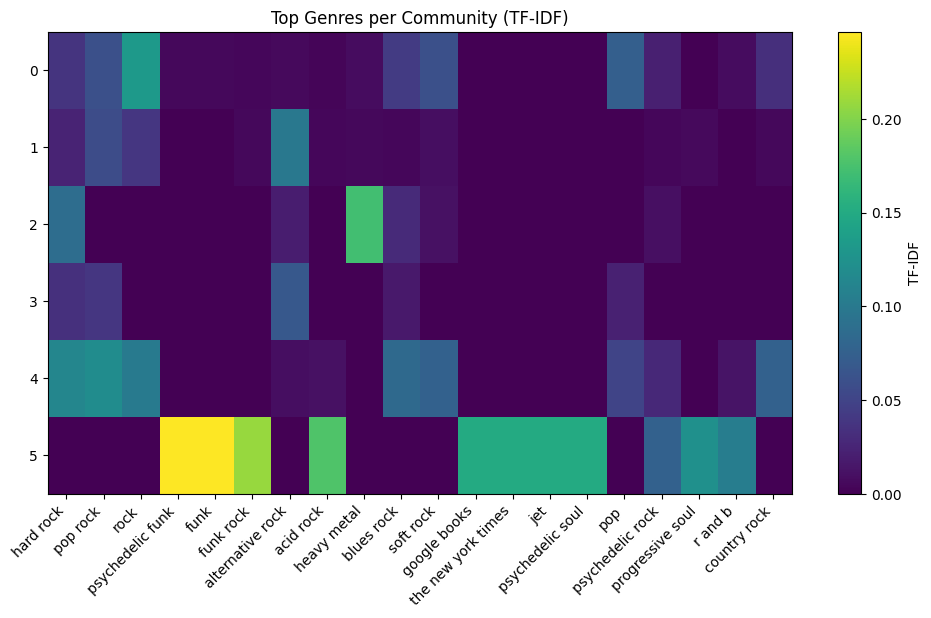

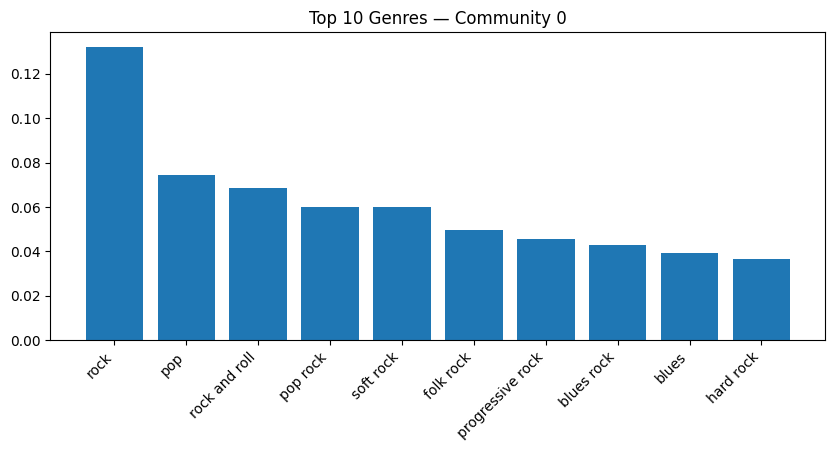

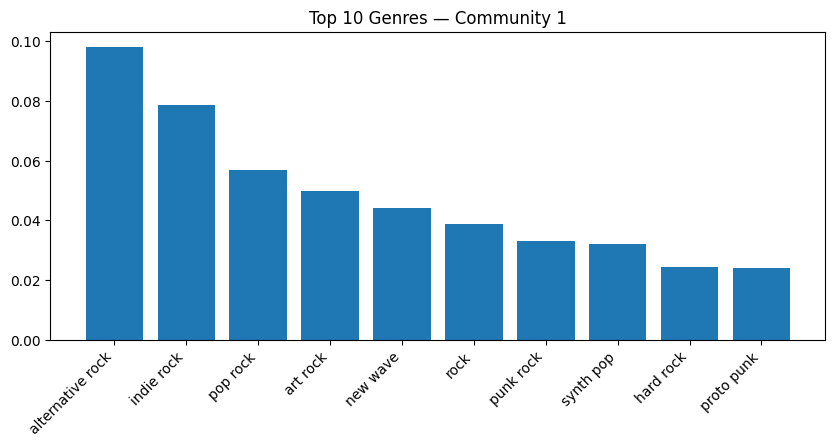

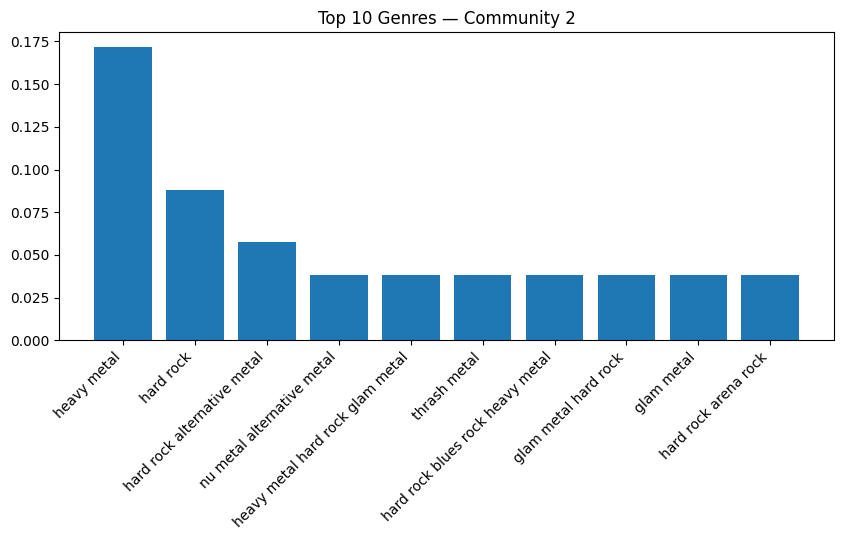

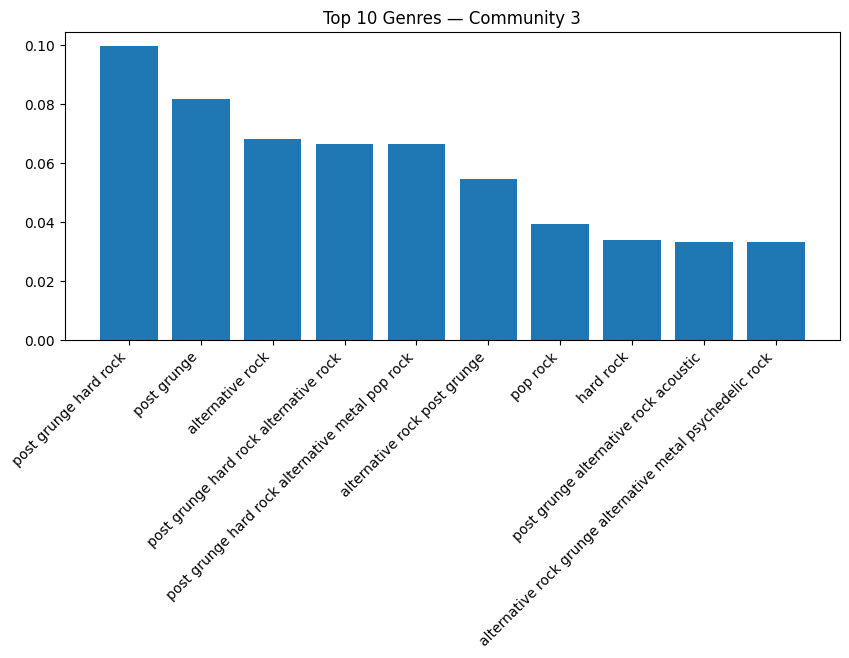

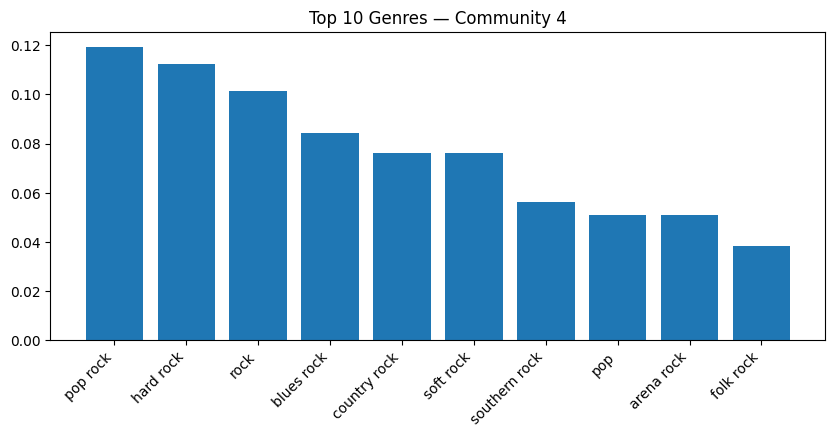

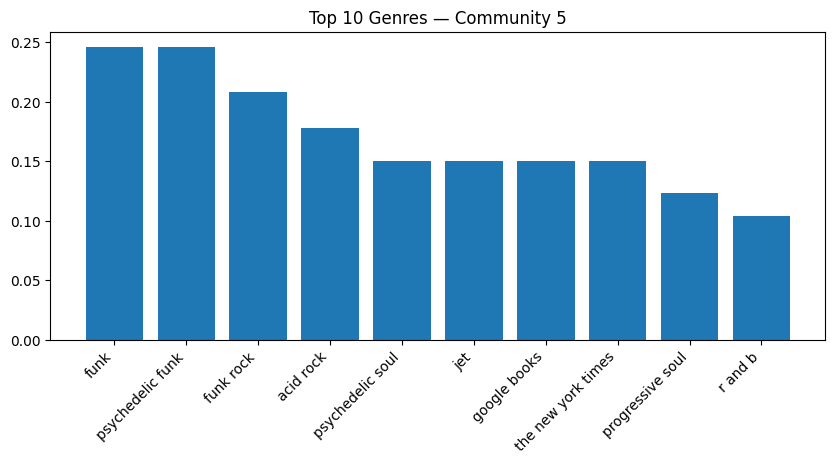

In [21]:
print(f"Found {len(communities)} communities using {method}.\n")

for i, nodes in enumerate(communities):
    print(f"🎸 Community {i} ({len(nodes)} artists):")
    print(", ".join(nodes[:5]) + (" ..." if len(nodes) > 5 else ""))
    print()

display(df_tfidf.head())

show_heatmap(df_tfidf, top_k=20)
show_top_bars(df_tfidf, top_n=10)

## Calculate and visualize TF-IDF for the genres and communities.

Using Louvain on the artist network, we found 5 communities (sizes: 150, 147, 89, 55, 3). Running TF-IDF on node genres highlights what’s distinctive for each group rather than what’s merely popular.

The network’s structure matches genre history: classic/roots, indie/alt, heavy/metal, post-grunge/alt-metal. TF-IDF surfaces what makes each cluster unique, letting us interpret communities as stylistic neighborhoods rather than generic “popularity.”

In [22]:
for node in G.nodes():
    for key, value in G.nodes[node].items():
        if isinstance(value, list):
            G.nodes[node][key] = ";".join(value)

# Save the graph for future use
nx.write_graphml(G, "rock_network_with_communities.graphml")


# Load enriched graph
#G = nx.read_graphml("rock_network_with_communities_and_sentiment.graphml")

node_genres = {
    n: [g.strip() for g in str(G.nodes[n].get("genres", "")).split(";") if g.strip()]
    for n in G.nodes()
}

# Community assignment
# Assume each node has a "community" attribute created earlier
node_comms = {n: G.nodes[n].get("community") for n in G.nodes()}

# Count genres overall
genre_counts = Counter([g for genres in node_genres.values() for g in genres])
top_genres = [g for g, _ in genre_counts.most_common(7)]

# Count communities by size
comm_counts = Counter([c for c in node_comms.values() if c is not None])
print("Community sizes:", comm_counts.most_common(7))
top_comms = [c for c, _ in comm_counts.most_common(7)]

print("Top genres:", top_genres)
print("Top communities:", top_comms)

# Build confusion matrix
matrix = pd.DataFrame(
    0, index=top_genres, columns=top_comms, dtype=int
)

for node in G.nodes():
    comm = node_comms[node]
    genres = node_genres[node]

    if comm not in top_comms:
        continue

    # consider all genres for that node
    for g in genres:
        if g in top_genres:
            matrix.loc[g, comm] += 1

print("\nConfusion matrix (genre x community):\n")
print(matrix)

# Normalize by row (optional, to interpret purity of genres by community)
row_norm = matrix.div(matrix.sum(axis=1), axis=0)
print("\nRow-normalized version:\n")
print(row_norm.round(2))


Community sizes: [(3, 150), (1, 147), (0, 89), (2, 55), (4, 40), (5, 3)]
Top genres: ['rock', 'pop rock', 'hard rock', 'alternative rock', 'blues rock', 'soft rock', 'pop']
Top communities: [3, 1, 0, 2, 4, 5]

Confusion matrix (genre x community):

                   3   1  0  2   4  5
rock              32   7  0  0   8  0
pop rock          17  12  0  2  11  0
hard rock         12   6  9  2  12  0
alternative rock   2  24  2  4   1  0
blues rock        14   1  3  1   9  0
soft rock         17   2  1  0   7  0
pop               18   0  0  1   4  0

Row-normalized version:

                     3     1     0     2     4    5
rock              0.68  0.15  0.00  0.00  0.17  0.0
pop rock          0.40  0.29  0.00  0.05  0.26  0.0
hard rock         0.29  0.15  0.22  0.05  0.29  0.0
alternative rock  0.06  0.73  0.06  0.12  0.03  0.0
blues rock        0.50  0.04  0.11  0.04  0.32  0.0
soft rock         0.63  0.07  0.04  0.00  0.26  0.0
pop               0.78  0.00  0.00  0.04  0.17  0.0


## Use the matrix d (Lecture 7, part 2) to dicusss the difference between the word-clouds between genres and communities.

Genres group by labels; communities group by network structure, so their word‑clouds need not match. The matrix shows where to expect overlap. Alternative rock is concentrated in community 1 (0.73), so its genre cloud should closely resemble community 1. Hard rock is split across communities 3 (0.29), 4 (0.29), and 0 (0.22), and pop rock across 3 (0.40), 1 (0.29), and 4 (0.26), so their genre clouds will blend multiple community vocabularies. Community 3 is the largest (150 nodes) and dominates rock (0.68), soft rock (0.63), and pop (0.78), so these genre clouds will reflect broad, high‑frequency terms typical of community 3. Blues rock shows a mixed profile with community 3 (0.50) and 4 (0.32). So to summarize: concentrated genres align with their main community; dispersed genres produce hybrid word‑clouds. This explains why community clouds can look sharper or broader than genre clouds even when they share many artists.

# Part 4 Calculate the sentiment of the band/artist pages (it is OK to work with the sub-network of artists-with-genre) and describe your findings using stats and visualization, inspired by the first exercise of week 8.

In [23]:
import re
import math
import requests
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import mwparserfromhell

%matplotlib inline

GRAPH_PATH = "rock_network_with_communities.graphml"
OUTPUT_GRAPH = "rock_network_with_communities_and_sentiment.graphml"

# Wikipedia API settings
WIKI_API = "https://en.wikipedia.org/w/api.php"
USER_AGENT = "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/142.0.0.0 Safari/537.36"
SESSION = requests.Session()
SESSION.headers.update({"User-Agent": USER_AGENT})


In [24]:
def download_labmt() -> dict:
    """Download the LabMT word list (TSV) and return dict: word -> happiness score (float)."""
    # Direct link to PLOS ONE supplementary data for 'Temporal Patterns of Happiness and Information...'
    url = "https://journals.plos.org/plosone/article/file?type=supplementary&id=info:doi/10.1371/journal.pone.0026752.s001"
    r = SESSION.get(url, timeout=60)
    r.raise_for_status()
    text = r.text
    labmt = {}
    # File has a header line; columns include 'word' and 'happiness_average' (or similar)
    lines = text.splitlines()
    if lines:

        word_idx=0
        happ_idx = 2
        for line in lines[3:]:
            parts = line.rstrip("\n").split("\t")
            if len(parts) <= max(word_idx, happ_idx):
                continue
            w = parts[word_idx].strip().lower()
            try:
                s = float(parts[happ_idx])
            except ValueError:
                continue
            if w:
                labmt[w] = s
    return labmt

labmt = download_labmt()
len(labmt), list(list(labmt.items())[:5])


(10222,
 [('laughter', 8.5),
  ('happiness', 8.44),
  ('love', 8.42),
  ('happy', 8.3),
  ('laughed', 8.26)])

In [25]:

def sentiment_score(tokens, labmt, drop_neutral=False, neutral_low=4.0, neutral_high=6.0):
    """
    Compute LabMT-style sentiment score for a list of lowercase tokens.
    If drop_neutral=True, words with happiness in [neutral_low, neutral_high] are ignored.
    Returns np.nan if no scored tokens remain.
    """
    scores = []
    for t in tokens:
        s = labmt.get(t)
        if s is None:
            continue
        if drop_neutral and (neutral_low <= s <= neutral_high):
            continue
        scores.append(s)
    if not scores:
        return np.nan
    return float(np.mean(scores))


In [26]:

def fetch_wikitext(title: str) -> str:
    params = {
        "action": "query",
        "format": "json",
        "prop": "revisions",
        "rvprop": "content",
        "rvslots": "main",
        "titles": title,
    }
    r = SESSION.get(WIKI_API, params=params, timeout=30)
    r.raise_for_status()
    data = r.json()
    pages = data.get("query", {}).get("pages", {})
    for _, page in pages.items():
        revs = page.get("revisions")
        if not revs:
            return ""
        return revs[0].get("slots", {}).get("main", {}).get("*", "")
    return ""


In [27]:

# Load the graph (only local file dependency)
G = nx.read_graphml(GRAPH_PATH)
print(f"Nodes: {G.number_of_nodes()}, Edges: {G.number_of_edges()}")

# Work on sub-network of artists that have a 'genres' attribute
nodes_with_genre = [n for n in G.nodes if G.nodes[n].get("genres")]
print(f"Artists with genres: {len(nodes_with_genre)}")

def get_page_text_for_node(n):
    # Prefer any stored text attributes if present
    for key in ["wikitext", "page_text", "text", "content"]:
        v = G.nodes[n].get(key)
        if v and isinstance(v, str) and len(v) > 50:
            return v
    # Otherwise fetch from Wikipedia
    title = str(n)
    wt = fetch_wikitext(title)
    return wt or ""

sentiment_map = {}
missing_text = 0

for i, n in enumerate(nodes_with_genre, 1):
    raw = get_page_text_for_node(n)
    if not raw:
        missing_text += 1
        sentiment_map[n] = np.nan
        continue
    # Strip wikitext to plain text
    plain = mwparserfromhell.parse(raw).strip_code()
    tokens = re.findall(r"[a-zA-Z']+", plain.lower())
    score = sentiment_score(tokens, labmt, drop_neutral=False)
    sentiment_map[n] = score
    G.nodes[n]["sentiment"] = score

print(f"Pages with missing/empty text: {missing_text}")


Nodes: 484, Edges: 7267
Artists with genres: 481
Pages with missing/empty text: 0


In [28]:
#Save the graph with sentiment attribute
nx.write_graphml(G, OUTPUT_GRAPH)
# Gather finite sentiment values
vals = np.array([v for v in sentiment_map.values() if isinstance(v, (int, float)) and not np.isnan(v)])

print(f"Valid sentiment pages: {len(vals)}")
if len(vals) == 0:
    raise RuntimeError("No valid sentiment values computed. Ensure pages have retrievable text.")

mean_s = float(np.mean(vals))
median_s = float(np.median(vals))
var_s = float(np.var(vals, ddof=1)) if len(vals) > 1 else float("nan")
q25 = float(np.percentile(vals, 25))
q75 = float(np.percentile(vals, 75))

summary = {
    "mean": round(mean_s, 3),
    "median": round(median_s, 3),
    "variance": round(var_s, 3) if not math.isnan(var_s) else None,
    "q25": round(q25, 3),
    "q75": round(q75, 3),
}
summary


Valid sentiment pages: 481


{'mean': 5.532, 'median': 5.531, 'variance': 0.003, 'q25': 5.496, 'q75': 5.569}

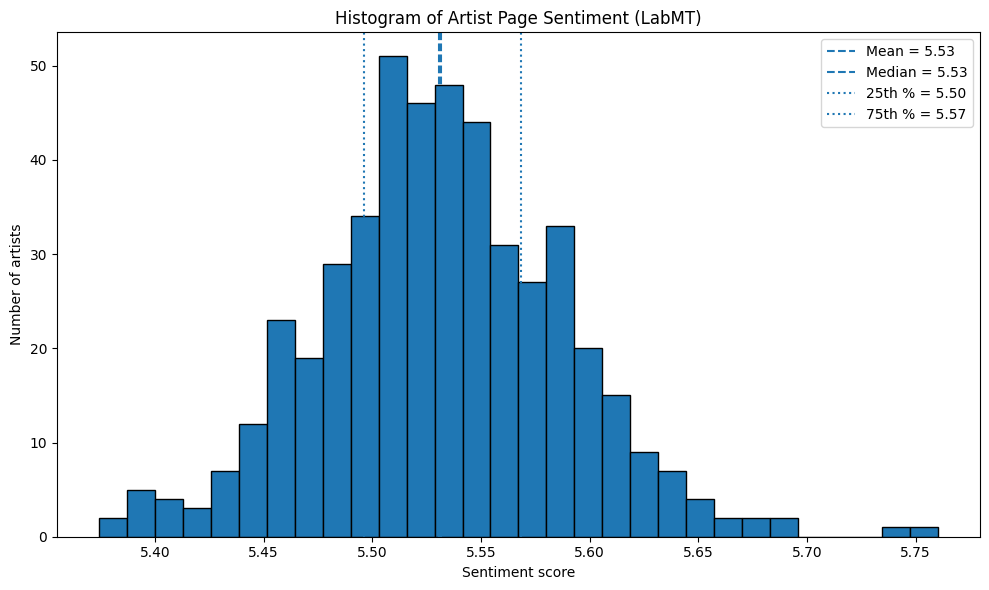

In [29]:
plt.figure(figsize=(10,6))
plt.hist(vals, bins=30, edgecolor="black")
plt.axvline(mean_s, linestyle="--", label=f"Mean = {mean_s:.2f}")
plt.axvline(median_s, linestyle="--", label=f"Median = {median_s:.2f}")
plt.axvline(q25, linestyle=":", label=f"25th % = {q25:.2f}")
plt.axvline(q75, linestyle=":", label=f"75th % = {q75:.2f}")
plt.title("Histogram of Artist Page Sentiment (LabMT)")
plt.xlabel("Sentiment score")
plt.ylabel("Number of artists")
plt.legend()
plt.tight_layout()


In [30]:
# Build sorted list of (artist, score)
pairs = [(n, s) for n, s in sentiment_map.items() if isinstance(s, (int, float)) and not np.isnan(s)]
pairs_sorted = sorted(pairs, key=lambda x: x[1], reverse=True)

top10_happy = pairs_sorted[:10]
top10_sad = pairs_sorted[-10:]

print("Top 10 happiest pages:")
for n, s in top10_happy:
    print(f"  {n}: {s:.3f}")
print("\nTop 10 saddest pages:")
for n, s in top10_sad:
    print(f"  {n}: {s:.3f}")


Top 10 happiest pages:
  Lenny Kravitz: 5.760
  Tracy Chapman: 5.741
  Michael Martin Murphey: 5.695
  The Boxtones: 5.690
  Fun (band): 5.674
  The Cardigans: 5.670
  Train (band): 5.668
  Royal Blood (band): 5.667
  Counting Crows: 5.649
  Simple Plan: 5.649

Top 10 saddest pages:
  W.A.S.P. (band): 5.402
  Quiet Riot: 5.401
  Pantera: 5.400
  Canned Heat: 5.398
  Skid Row (American band): 5.398
  Sex Pistols: 5.396
  Five Finger Death Punch: 5.396
  Rage Against the Machine: 5.393
  Marilyn Manson: 5.385
  Gary Glitter: 5.374


### Calculate the sentiment of the band/artist pages (it is OK to work with the sub-network of artists-with-genre) and describe your findings using stats and visualization, inspired by the first exercise of week 8.

The sentiment distribution of artist Wikipedia pages is **high and tightly clustered**:

| Metric | Value |
|---|---|
| Mean | 5.532 |
| Median | 5.531 |
| 25% | 5.496 |
| 75% | 5.569 |
| Variance | 0.003 |

A LabMT score above ~5 indicates positive language, so most pages lean **consistently positive**, with very little spread. This fits Wikipedia’s tone - career achievements, awards, and legacy tend to dominate over conflict or tragedy.


### Summary

Wikipedia biographies for rock artists tend to use **neutral-to-positive language**, focusing on career highlights. A few controversial or politically charged acts pull sentiment down, but the overall emotional tone remains upbeat and consistent.


## Sentiment of artist pages (LabMT) — results and brief discussion


**Summary statistics**

| Metric   | Value |
| -------- | ----- |
| Mean     | 5.532 |
| Median   | 5.531 |
| 25%      | 5.496 |
| 75%      | 5.569 |
| Variance | 0.003 |

**Interpretation**

* Scores are centred around 5.53 with a small variance , indicating a tight, mildly positive distribution. Median and mean are almost identical, which suggests near symmetry.
* Relative to the LabMT neutral baseline near 5, artist pages lean slightly positive, consistent with descriptive and promotional language on Wikipedia‑style pages.
* The histogram looks bell‑shaped with modest tails. The happiest pages reach about 5.76; the saddest reach about 5.37. There are few extreme outliers.

**Top pages**

*Happiest (top 10)*: Lenny Kravitz (5.760), Tracy Chapman (5.741), Michael Martin Murphey (5.695), The Boxtones (5.690), Fun (band) (5.674), The Cardigans (5.670), Train (band) (5.668), Royal Blood (band) (5.667), Counting Crows (5.649), Simple Plan (5.649).

*Saddest (top 10)*: W.A.S.P. (band) (5.402), Quiet Riot (5.401), Pantera (5.400), Canned Heat (5.398), Skid Row (American band) (5.398), Sex Pistols (5.396), Five Finger Death Punch (5.396), Rage Against the Machine (5.393), Marilyn Manson (5.385), Gary Glitter (5.374).


Artist pages in the genre‑tagged sub‑network exhibit a narrow, near‑normal distribution of LabMT sentiment with a mean around 5.53 and small dispersion, implying broadly positive but not extreme language. The close agreement between mean and median and the narrow IQR indicate limited skew. The extremes are modest, suggesting that page tone varies by topic but remains mostly informative and neutral‑to‑positive overall. This matches expectations for encyclopedic descriptions that emphasise releases, awards, and reception rather than highly emotional language.

[0, 1, 2, 3, 4, 5]
   community  n_total  n_with_sent  coverage   mean  median    q25    q75  \
2          2       55           54     0.982  5.556   5.548  5.532  5.585   
1          1      147          147     1.000  5.546   5.545  5.514  5.585   
4          4       40           40     1.000  5.539   5.535  5.513  5.581   
3          3      150          149     0.993  5.528   5.517  5.494  5.555   
0          0       89           88     0.989  5.499   5.500  5.456  5.536   
5          5        3            3     1.000  5.486   5.489  5.471  5.502   

      sd  delta_vs_global                                               top3  \
2  0.051            0.024  [(Tracy Chapman, 5.741), (Counting Crows, 5.64...   
1  0.055            0.014  [(Fun (band), 5.674), (The Cardigans, 5.67), (...   
4  0.054            0.007  [(Kenny Loggins, 5.646), (Edgar Winter, 5.641)...   
3  0.052           -0.004  [(Lenny Kravitz, 5.76), (Michael Martin Murphe...   
0  0.058           -0.033  [(Living Colou

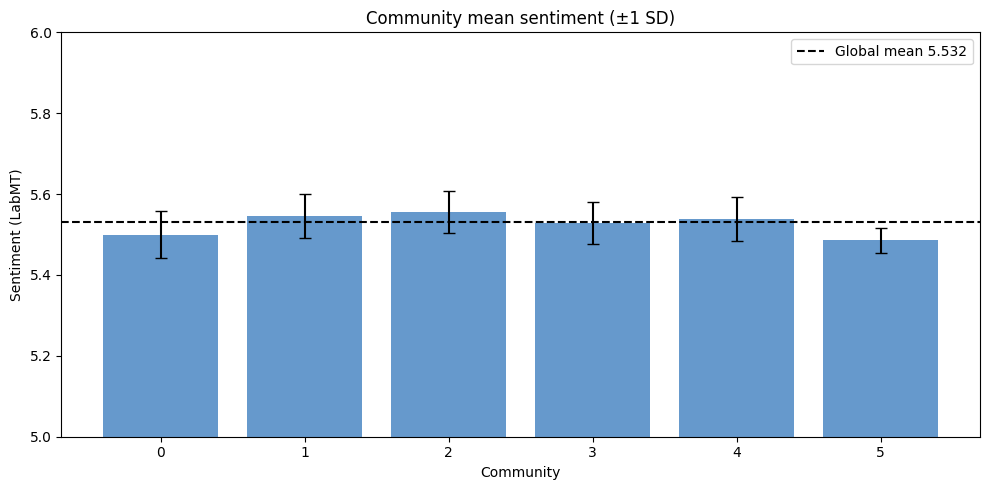


Interpretation:
 - Highest mean: community 2 at 5.556 (n=54/55 coverage=0.98).
 - Lowest mean: community 5 at 5.486 (n=3/3 coverage=1.00).
 - Spread: 0.070.
 - Top examples in best community: [('Tracy Chapman', 5.741), ('Counting Crows', 5.649), ('Matchbox Twenty', 5.648)]
 - Bottom examples in worst community: [('Parliament (band)', 5.453), ('Parliament-Funkadelic', 5.489), ('Funkadelic', 5.514)]


In [31]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from collections import defaultdict

G = nx.read_graphml(OUTPUT_GRAPH)

def _as_comm(c):
    try:
        return int(c)
    except Exception:
        return c

def _to_float(x):
    if x is None:
        return None
    try:
        v = float(x)
        if np.isnan(v):
            return None
        return v
    except (TypeError, ValueError):
        return None

# Group sentiments by community and track total membership size
groups = defaultdict(list)      # comm -> list of (node, sentiment)
counts_by_comm = defaultdict(int)

for n, attrs in G.nodes(data=True):
    c = _as_comm(attrs.get("community"))
    if c is None:
        continue
    counts_by_comm[c] += 1
    s = _to_float(attrs.get("sentiment"))
    if s is not None:
        groups[c].append((n, s))

# Global sentiment over all nodes that have a sentiment
all_sents = [s for pairs in groups.values() for (_, s) in pairs]
if not all_sents:
    raise RuntimeError("Found no numeric 'sentiment' values. Ensure the graph contains the attribute or adjust attribute name.")

global_mean = float(np.mean(all_sents))
global_sd = float(np.std(all_sents, ddof=1)) if len(all_sents) > 1 else float("nan")

# Build per-community summary
summary_rows = []
print(sorted(counts_by_comm.keys(), key=lambda x: (isinstance(x, str), x)))
for c in sorted(counts_by_comm.keys(), key=lambda x: (isinstance(x, str), x)):
    sents = [s for (_, s) in groups.get(c, [])]
    n_total = counts_by_comm[c]
    n_with_sent = len(sents)
    if n_with_sent:
        mean = float(np.mean(sents))
        median = float(np.median(sents))
        q25 = float(np.percentile(sents, 25))
        q75 = float(np.percentile(sents, 75))
        sd = float(np.std(sents, ddof=1)) if n_with_sent > 1 else float("nan")
    else:
        mean = median = q25 = q75 = sd = float("nan")

    top3 = sorted(groups.get(c, []), key=lambda x: x[1], reverse=True)[:3]
    bottom3 = sorted(groups.get(c, []), key=lambda x: x[1])[:3]

    summary_rows.append({
        "community": c,
        "n_total": n_total,
        "n_with_sent": n_with_sent,
        "coverage": round(n_with_sent / n_total, 3) if n_total else 0.0,
        "mean": round(mean, 3) if not np.isnan(mean) else None,
        "median": round(median, 3) if not np.isnan(median) else None,
        "q25": round(q25, 3) if not np.isnan(q25) else None,
        "q75": round(q75, 3) if not np.isnan(q75) else None,
        "sd": round(sd, 3) if not np.isnan(sd) else None,
        "delta_vs_global": round((mean - global_mean), 3) if not np.isnan(mean) else None,
        "top3": [(n, round(s, 3)) for (n, s) in top3],
        "bottom3": [(n, round(s, 3)) for (n, s) in bottom3],
    })

import pandas as pd
summary_df = pd.DataFrame(summary_rows).sort_values("mean", ascending=False, na_position="last")
#display(summary_df)
print(summary_df)


print(f"\nGlobal sentiment mean = {global_mean:.3f} (sd={global_sd:.3f}) over {len(all_sents)} artists.")

# Bar plot: community means ±1 SD, with global mean line
valid_rows = [r for r in summary_rows if r["mean"] is not None]
comm_ids = [str(r["community"]) for r in valid_rows]
means = [r["mean"] for r in valid_rows]
errs = [r["sd"] if r["sd"] is not None else 0.0 for r in valid_rows]

plt.figure(figsize=(10, 5))
plt.bar(comm_ids, means, yerr=errs, capsize=4, color="#6699cc")
plt.axhline(global_mean, color="k", linestyle="--", label=f"Global mean {global_mean:.3f}")
plt.xlabel("Community")
plt.ylabel("Sentiment (LabMT)")
plt.title("Community mean sentiment (±1 SD)")
plt.ylim(5, 6)
plt.legend()
plt.tight_layout()
plt.show()

# Quick textual interpretation helpers
if valid_rows:
    best = max(valid_rows, key=lambda r: r["mean"])
    worst = min(valid_rows, key=lambda r: r["mean"])
    spread = best["mean"] - worst["mean"]
    print("\nInterpretation:")
    print(f" - Highest mean: community {best['community']} at {best['mean']:.3f} (n={best['n_with_sent']}/{best['n_total']} coverage={best['coverage']:.2f}).")
    print(f" - Lowest mean: community {worst['community']} at {worst['mean']:.3f} (n={worst['n_with_sent']}/{worst['n_total']} coverage={worst['coverage']:.2f}).")
    print(f" - Spread: {spread:.3f}.")
    print(f" - Top examples in best community: {best['top3']}")
    print(f" - Bottom examples in worst community: {worst['bottom3']}")

## Discuss the sentiment of the communities. Do the findings using TF-IDF during Lecture 7 help you understand your results?


The average sentiment in the network is 5.532 on the LabMT scale, showing a slightly positive tone overall. When sentiment is broken down by community, the group means remain very close to this global value. All communities fall within a narrow range around the global mean, and their error bars overlap. This indicates that there are no strong differences in page sentiment across structural groups.

Communities 1 through 4 sit just above or around the overall mean, while communities 0 and 5 are slightly below. The spread between the highest and lowest community averages is small and well under one standard deviation. This suggests that even though artists cluster structurally in the collaboration network, the language used on their pages remains consistently neutral to positive across clusters.

In summary, sentiment does not appear to be strongly structured by community. The encyclopedia style of the text likely dominates, leading to limited variation across groups despite different musical styles or network positions.


# Contributions

**Part 1 and 2 where made by Marcus Lilleør Christoffersen s224750**

**Part 3 and 4 where made by Oliver Badike Hansen s224754**